In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import neurokit2 as nk
from scipy import signal

plt.rcParams["figure.figsize"] = (15, 4)

In [2]:
DATASET_PATH = "../data/WESAD"
subject = "S2"

with open(os.path.join(DATASET_PATH, subject, f"{subject}.pkl"), "rb") as f:
    data = pickle.load(f, encoding="latin1")

ecg_raw = data["signal"]["chest"]["ECG"].squeeze()
labels = data["label"]

FS_RAW = 700  # Hz

/tmp/ipykernel_30563/2110105343.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")


In [3]:
VALID_LABELS = [1, 2]  # baseline, stress

mask = np.isin(labels, VALID_LABELS)

ecg_raw = ecg_raw[mask]
labels = labels[mask]

In [4]:
FS = 250

num_samples = int(len(ecg_raw) * FS / FS_RAW)

ecg_ds = signal.resample(ecg_raw, num_samples)
labels_ds = signal.resample(labels, num_samples).round().astype(int)

In [5]:
ecg_clean = nk.ecg_clean(ecg_ds, sampling_rate=FS)

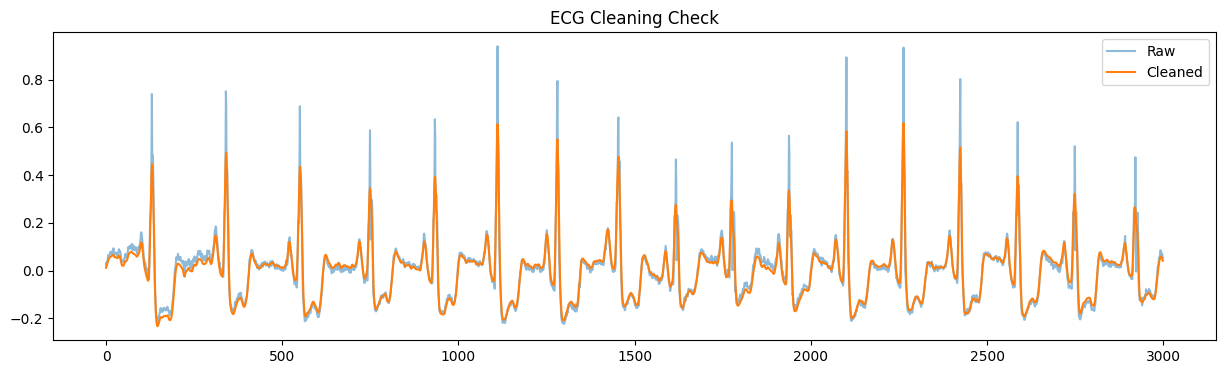

In [6]:
plt.plot(ecg_ds[:3000], label="Raw", alpha=0.5)
plt.plot(ecg_clean[:3000], label="Cleaned")
plt.legend()
plt.title("ECG Cleaning Check")
plt.show()

In [7]:
signals, info = nk.ecg_peaks(ecg_clean, sampling_rate=FS)
rpeaks = info["ECG_R_Peaks"]

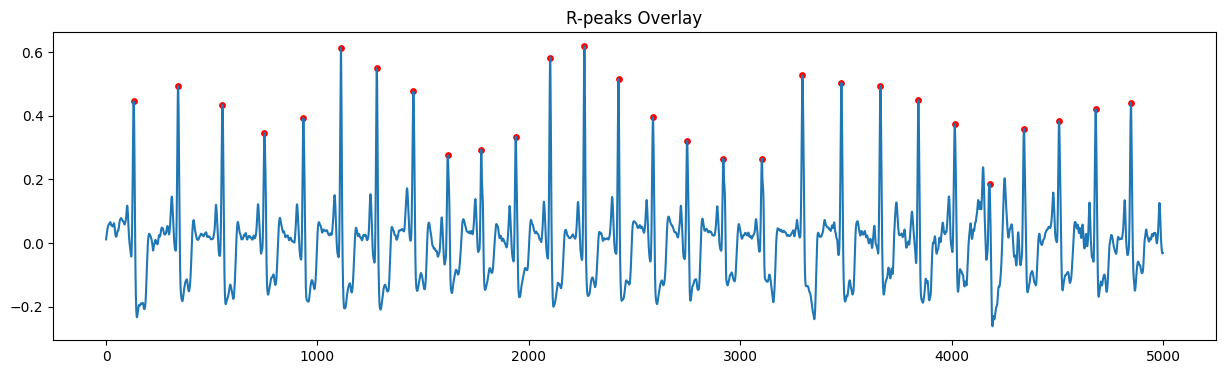

In [8]:
plt.plot(ecg_clean[:5000])
plt.scatter(rpeaks[rpeaks < 5000], ecg_clean[rpeaks[rpeaks < 5000]],
            color="red", s=15)
plt.title("R-peaks Overlay")
plt.show()

In [9]:
rr_intervals = np.diff(rpeaks) / FS  # seconds

In [10]:
rr_clean = rr_intervals[(rr_intervals > 0.3) & (rr_intervals < 2.0)]

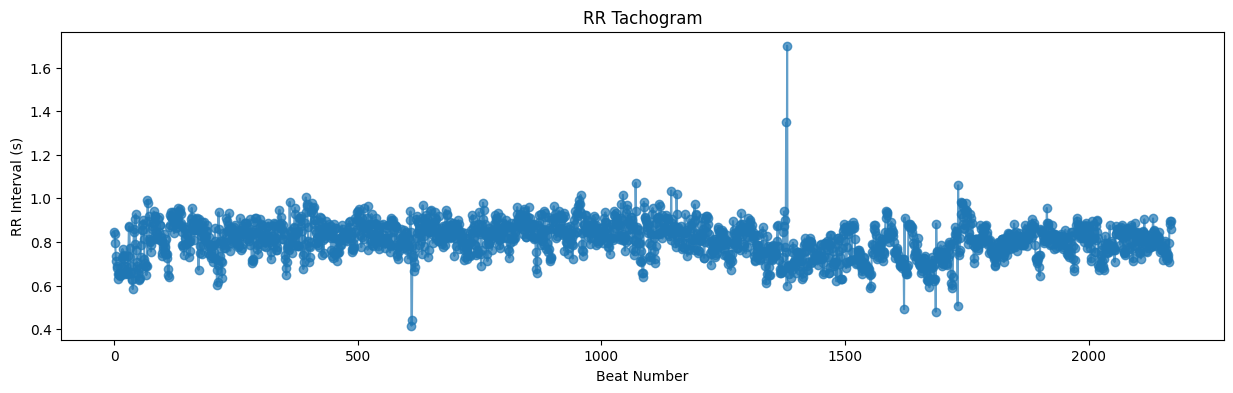

In [11]:
plt.plot(rr_clean, marker="o", linestyle="-", alpha=0.7)
plt.xlabel("Beat Number")
plt.ylabel("RR Interval (s)")
plt.title("RR Tachogram")
plt.show()

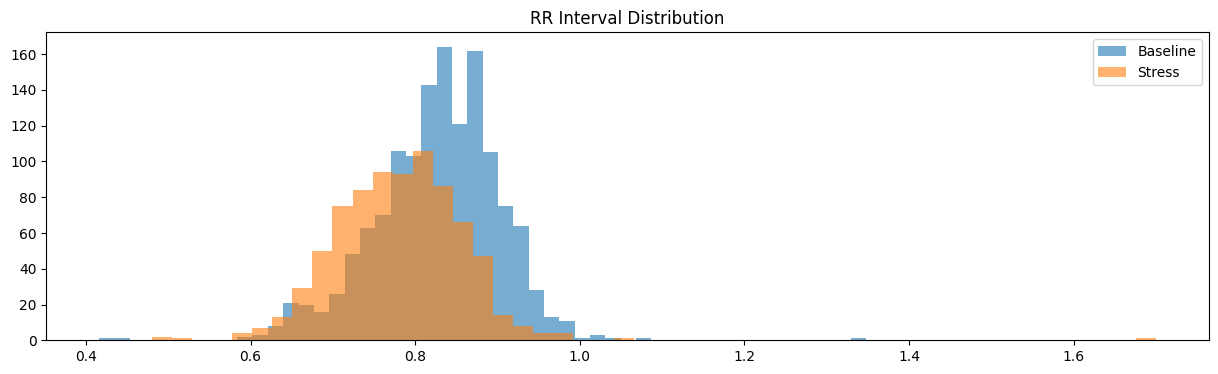

In [12]:
rr_labels = labels_ds[rpeaks[1:]]  # align RR with labels

rr_baseline = rr_intervals[rr_labels == 1]
rr_stress = rr_intervals[rr_labels == 2]

plt.hist(rr_baseline, bins=50, alpha=0.6, label="Baseline")
plt.hist(rr_stress, bins=50, alpha=0.6, label="Stress")
plt.legend()
plt.title("RR Interval Distribution")
plt.show()

# Saving the data

In [17]:
subjects = sorted([d for d in os.listdir(DATASET_PATH) if d.startswith("S")])
subjects

['S10',
 'S11',
 'S13',
 'S14',
 'S15',
 'S16',
 'S17',
 'S2',
 'S3',
 'S4',
 'S5',
 'S6',
 'S7',
 'S8',
 'S9']

In [18]:
import pickle
import numpy as np
from scipy import signal
import neurokit2 as nk

FS_RAW = 700
FS = 250
VALID_LABELS = [1, 2]  # baseline, stress

def process_subject(subject, dataset_path):
    with open(os.path.join(dataset_path, subject, f"{subject}.pkl"), "rb") as f:
        data = pickle.load(f, encoding="latin1")

    ecg = data["signal"]["chest"]["ECG"].squeeze()
    labels = data["label"]

    # Filter labels
    mask = np.isin(labels, VALID_LABELS)
    ecg = ecg[mask]
    labels = labels[mask]

    # Downsample
    num_samples = int(len(ecg) * FS / FS_RAW)
    ecg_ds = signal.resample(ecg, num_samples)
    labels_ds = signal.resample(labels, num_samples).round().astype(int)

    # Clean ECG
    ecg_clean = nk.ecg_clean(ecg_ds, sampling_rate=FS)

    # R-peaks
    _, info = nk.ecg_peaks(ecg_clean, sampling_rate=FS)
    rpeaks = info["ECG_R_Peaks"]

    # RR intervals
    rr_intervals = np.diff(rpeaks) / FS
    rr_clean = rr_intervals[(rr_intervals > 0.3) & (rr_intervals < 2.0)]

    # Align labels to RR
    rr_labels = labels_ds[rpeaks[1:]]
    rr_labels = rr_labels[(rr_intervals > 0.3) & (rr_intervals < 2.0)]

    return rpeaks, rr_clean, rr_labels

In [19]:
import os

SAVE_PATH = "../data/processed/wesad"
os.makedirs(SAVE_PATH, exist_ok=True)

for subject in subjects:
    try:
        rpeaks, rr_intervals, rr_labels = process_subject(subject, DATASET_PATH)

        save_file = os.path.join(SAVE_PATH, f"{subject}_rr.npz")
        np.savez(
            save_file,
            rpeaks=rpeaks,
            rr_intervals=rr_intervals,
            rr_labels=rr_labels,
            fs=FS
        )

        print(f"Saved {subject} ({len(rr_intervals)} RR intervals)")

    except Exception as e:
        print(f"❌ Failed for {subject}: {e}")


/tmp/ipykernel_30563/1461980280.py:12: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")


Saved S10 (3235 RR intervals)


/tmp/ipykernel_30563/1461980280.py:12: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")


Saved S11 (2869 RR intervals)


/tmp/ipykernel_30563/1461980280.py:12: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")


...

Saved S7 (2290 RR intervals)


/tmp/ipykernel_30563/1461980280.py:12: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")


Saved S8 (2384 RR intervals)


/tmp/ipykernel_30563/1461980280.py:12: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")


Saved S9 (2365 RR intervals)


In [20]:
# Sanity Check
data_rr = np.load("../data/processed/wesad/S17_rr.npz")
print(data_rr.files)
print(data_rr["rr_intervals"][:10])


['rpeaks', 'rr_intervals', 'rr_labels', 'fs']
[0.688 0.692 0.704 0.66  0.68  0.724 0.688 0.652 0.608 0.612]
